# ASVspoof5 Train-Only Probe (Tuned) ? train+val -> test with Per-User Evaluation

Trains a tuned global probe (speaker-disjoint validation inside `B`) and reports per-user metrics for all `B` and `C` users.


In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchaudio
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_ROOT = Path("/home/SpeakerRec/BioVoice")
MANIFEST_PATH = PROJECT_ROOT / "redimnet" / "logistic_regression" / "asvspoof5" / "100_speakers" / "asvspoof5_100_speakers_selected_utterances_plan.csv"
SUBSET_AUDIO_ROOT = PROJECT_ROOT / "data" / "datasets" / "asvspoof5_100_speakers_32_real_48_spoof"
EMBED_CACHE_DIR = PROJECT_ROOT / "data" / "embeddings" / "asvspoof5_100_speakers_32_real_48_spoof"
EMBED_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Tuning config (speaker-disjoint split inside group train)
VAL_SPEAKER_COUNT = 0      # unused when manifest already provides 'val' group
TUNE_SEED = 42
C_GRID = [0.01, 0.1, 1.0, 10.0]
CLASS_WEIGHT_OPTIONS = [None, 'balanced']
THRESH_GRID = np.linspace(0.05, 0.95, 181)
FORCE_RECOMPUTE_EMBEDDINGS = False

print("DEVICE:", DEVICE)
print("MANIFEST_PATH:", MANIFEST_PATH)
print("SUBSET_AUDIO_ROOT:", SUBSET_AUDIO_ROOT)

OUT_DIR = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_100_speakers_probe_train_val_test_per_user_tuned'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_NPZ = EMBED_CACHE_DIR / 'embeddings_train_val_test_global.npz'


DEVICE: cuda
MANIFEST_PATH: /home/SpeakerRec/BioVoice/redimnet/logistic_regression/asvspoof5/100_speakers/asvspoof5_100_speakers_selected_utterances_plan.csv
SUBSET_AUDIO_ROOT: /home/SpeakerRec/BioVoice/data/datasets/asvspoof5_100_speakers_32_real_48_spoof


In [3]:
LABEL_MAP = {"bonafide": 0, "spoof": 1}


def build_audio_path(row, subset_root: Path) -> Path:
    return subset_root / str(row["group"]) / str(row["label"]) / f"{row['utt_id']}.flac"


def load_manifest(manifest_path: Path, subset_root: Path) -> pd.DataFrame:
    df = pd.read_csv(manifest_path).copy()
    req = {"group","speaker_id","utt_id","label","system_id"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"Manifest missing columns: {sorted(missing)}")
    df["label_str"] = df["label"].astype(str)
    df["label_id"] = df["label_str"].map(LABEL_MAP).astype(int)
    df["audio_path"] = df.apply(lambda r: str(build_audio_path(r, subset_root)), axis=1)
    df["audio_exists"] = df["audio_path"].map(lambda p: Path(p).exists())
    return df


def embed_with_redim(model, wav_path: str, device: str) -> np.ndarray:
    wav, sr = torchaudio.load(wav_path)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
    if wav.shape[0] > 1:
        wav = wav[:1, :]
    wav = wav.to(device)
    with torch.no_grad():
        emb = model(wav)
    return emb.squeeze(0).detach().cpu().numpy().astype(np.float32)


def extract_embeddings_for_df(df_paths: pd.DataFrame, model, device: str, cache_npz: Path, force_recompute: bool=False):
    if cache_npz.exists() and not force_recompute:
        payload = np.load(cache_npz, allow_pickle=True)
        X = payload['X']
        utt_ids = payload['utt_ids'].astype(str)
        lut = pd.DataFrame({'utt_id': utt_ids, '_idx': np.arange(len(utt_ids))})
        m = df_paths[['utt_id']].merge(lut, on='utt_id', how='left', validate='one_to_one')
        if m['_idx'].isna().any():
            miss = m.loc[m['_idx'].isna(), 'utt_id'].tolist()[:10]
            raise RuntimeError(f"Embedding cache missing utt_ids, examples: {miss}")
        return X[m['_idx'].astype(int).to_numpy()]

    vecs, ids = [], []
    for rec in tqdm(df_paths.to_dict('records'), desc=f"Embedding {len(df_paths)}"):
        p = Path(rec['audio_path'])
        if not p.exists():
            raise FileNotFoundError(f"Missing audio: {p}")
        vecs.append(embed_with_redim(model, str(p), device))
        ids.append(str(rec['utt_id']))
    X = np.stack(vecs).astype(np.float32)
    np.savez_compressed(cache_npz, X=X, utt_ids=np.array(ids, dtype=object))
    return X


def split_B_speakers(df: pd.DataFrame, n_val_speakers=3, seed=42):
    # Uses explicit pre-defined groups in manifest: train/val/test
    train_speakers = sorted(df.loc[df['group'].eq('train'), 'speaker_id'].astype(str).unique().tolist())
    val_speakers = sorted(df.loc[df['group'].eq('val'), 'speaker_id'].astype(str).unique().tolist())
    if len(train_speakers) == 0 or len(val_speakers) == 0:
        raise ValueError('Expected non-empty train and val speaker groups in manifest')
    return train_speakers, val_speakers


def metrics_at_threshold(y_true, p1, thr):
    y_hat = (p1 >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat).tolist()
    out = {
        'threshold': float(thr),
        'accuracy': float(accuracy_score(y_true, y_hat)),
        'auc': float(roc_auc_score(y_true, p1)) if len(np.unique(y_true)) == 2 else None,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_hat, output_dict=True, zero_division=0),
    }
    # balanced accuracy (manual to avoid extra import)
    tn, fp = cm[0]
    fn, tp = cm[1]
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    out['balanced_accuracy'] = float((tnr + tpr) / 2.0)
    out['bonafide_recall'] = float(tnr)
    out['spoof_recall'] = float(tpr)
    return out, y_hat


def tune_logreg_with_speaker_val(X, y, df_meta, c_grid, class_weight_options, thresh_grid, val_speaker_count=3, seed=42):
    b_train_speakers, b_val_speakers = split_B_speakers(df_meta, n_val_speakers=val_speaker_count, seed=seed)
    is_b_train = df_meta['group'].eq('train')
    is_b_val = df_meta['group'].eq('val')
    is_c_test = df_meta['group'].eq('test')

    if not (is_b_train.any() and is_b_val.any() and is_c_test.any()):
        raise ValueError('Expected train/val/test groups in task dataframe')

    X_btr, y_btr = X[is_b_train.to_numpy()], y[is_b_train.to_numpy()]
    X_bval, y_bval = X[is_b_val.to_numpy()], y[is_b_val.to_numpy()]
    is_train_or_val = df_meta['group'].isin(['train', 'val'])
    X_B, y_B = X[is_train_or_val.to_numpy()], y[is_train_or_val.to_numpy()]
    X_C, y_C = X[is_c_test.to_numpy()], y[is_c_test.to_numpy()]

    best = None
    tuning_rows = []
    for cw in class_weight_options:
        for cval in c_grid:
            scaler = StandardScaler()
            X_btr_s = scaler.fit_transform(X_btr)
            X_bval_s = scaler.transform(X_bval)
            clf = LogisticRegression(max_iter=2000, C=float(cval), class_weight=cw, random_state=42)
            clf.fit(X_btr_s, y_btr)
            p_bval = clf.predict_proba(X_bval_s)[:, 1]
            for thr in thresh_grid:
                m_val, _ = metrics_at_threshold(y_bval, p_bval, float(thr))
                row = {
                    'C': float(cval),
                    'class_weight': str(cw),
                    'threshold': float(thr),
                    'val_balanced_accuracy': m_val['balanced_accuracy'],
                    'val_accuracy': m_val['accuracy'],
                    'val_auc': m_val['auc'],
                    'val_bonafide_recall': m_val['bonafide_recall'],
                    'val_spoof_recall': m_val['spoof_recall'],
                }
                tuning_rows.append(row)
                key = (m_val['balanced_accuracy'], m_val['accuracy'], m_val['auc'] if m_val['auc'] is not None else -1.0)
                if best is None or key > best['_key']:
                    best = {'_key': key, **row}

    # retrain final model on train+val using selected hyperparameters
    final_scaler = StandardScaler()
    X_B_s = final_scaler.fit_transform(X_B)
    X_C_s = final_scaler.transform(X_C)
    final_clf = LogisticRegression(
        max_iter=2000,
        C=float(best['C']),
        class_weight=(None if best['class_weight'] == 'None' else 'balanced'),
        random_state=42,
    )
    final_clf.fit(X_B_s, y_B)
    p_B = final_clf.predict_proba(X_B_s)[:, 1]
    p_C = final_clf.predict_proba(X_C_s)[:, 1]

    chosen_thr = float(best['threshold'])
    m_B, yhat_B = metrics_at_threshold(y_B, p_B, chosen_thr)
    m_C, yhat_C = metrics_at_threshold(y_C, p_C, chosen_thr)

    # default threshold reference (0.5) on test for comparison
    m_C_default, yhat_C_default = metrics_at_threshold(y_C, p_C, 0.5)

    result = {
        'b_train_speakers': b_train_speakers,
        'b_val_speakers': b_val_speakers,
        'best_params': {k: best[k] for k in ['C','class_weight','threshold','val_balanced_accuracy','val_accuracy','val_auc','val_bonafide_recall','val_spoof_recall']},
        'metrics_train_val_tuned_threshold': m_B,
        'metrics_test_tuned_threshold': m_C,
        'metrics_test_default_threshold_0_5': m_C_default,
    }

    masks = {
        'is_B': df_meta['group'].isin(['train', 'val']).to_numpy(),
        'is_C': df_meta['group'].eq('test').to_numpy(),
    }
    tuning_df = pd.DataFrame(tuning_rows).sort_values(['val_balanced_accuracy','val_accuracy','val_auc'], ascending=False)
    return final_scaler, final_clf, chosen_thr, p_B, p_C, yhat_B, yhat_C, yhat_C_default, result, tuning_df, masks



def plot_confmat(cm, title):
    cm = np.array(cm)
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['bonafide','spoof'], rotation=30, ha='right')
    ax.set_yticklabels(['bonafide','spoof'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for (i,j), v in np.ndenumerate(cm):
        ax.text(j, i, str(int(v)), ha='center', va='center')
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    return fig


In [4]:
redim_model = (
    torch.hub.load(
        "IDRnD/ReDimNet",
        "ReDimNet",
        model_name="b5",
        train_type="ptn",
        dataset="vox2",
    )
    .to(DEVICE)
    .eval()
)
print("Loaded ReDimNet on", DEVICE)


Using cache found in /home/SpeakerRec/.cache/torch/hub/IDRnD_ReDimNet_master


Loaded ReDimNet on cuda


In [5]:
manifest_df = load_manifest(MANIFEST_PATH, SUBSET_AUDIO_ROOT)
bc_df = manifest_df[manifest_df['group'].isin(['train','val','test'])].copy().reset_index(drop=True)
X_bc = extract_embeddings_for_df(bc_df[['utt_id','audio_path']], redim_model, DEVICE, CACHE_NPZ, force_recompute=FORCE_RECOMPUTE_EMBEDDINGS)
y_bc = bc_df['label_id'].to_numpy().astype(int)

scaler, clf, thr, p_B, p_C, yhat_B, yhat_C, yhat_C_default, results, tuning_df, masks = tune_logreg_with_speaker_val(
    X_bc, y_bc, bc_df, C_GRID, CLASS_WEIGHT_OPTIONS, THRESH_GRID, val_speaker_count=VAL_SPEAKER_COUNT, seed=TUNE_SEED
)
print('Chosen threshold:', thr)
print('Global test accuracy (test, tuned thr):', results['metrics_test_tuned_threshold']['accuracy'])
print('Global test accuracy (test, thr=0.5):', results['metrics_test_default_threshold_0_5']['accuracy'])


Embedding 8000: 100%|██████████| 8000/8000 [10:52<00:00, 12.26it/s]


Chosen threshold: 0.595
Global test accuracy (test, tuned thr): 0.8775
Global test accuracy (test, thr=0.5): 0.865625


In [6]:
pred_B = bc_df.loc[masks['is_B'], ['group','speaker_id','utt_id','label_str','label_id','system_id']].copy().reset_index(drop=True)
pred_B['split'] = 'train_val'
pred_B['prob_spoof'] = p_B
pred_B['pred_label_id'] = yhat_B

pred_C = bc_df.loc[masks['is_C'], ['group','speaker_id','utt_id','label_str','label_id','system_id']].copy().reset_index(drop=True)
pred_C['split'] = 'test'
pred_C['prob_spoof'] = p_C
pred_C['pred_label_id'] = yhat_C

pred_all = pd.concat([pred_B, pred_C], ignore_index=True)
pred_all['pred_label_str'] = pred_all['pred_label_id'].map({0:'bonafide',1:'spoof'})

rows = []
for (split, spk), g in pred_all.groupby(['split','speaker_id']):
    y_t = g['label_id'].to_numpy(); p = g['prob_spoof'].to_numpy(); y_h = g['pred_label_id'].to_numpy()
    cm = confusion_matrix(y_t, y_h).tolist()
    tn, fp = cm[0]; fn, tp = cm[1]
    rows.append({
        'split': split,
        'group': g['group'].iloc[0],
        'speaker_id': spk,
        'n_samples': int(len(g)),
        'n_bonafide': int((y_t==0).sum()),
        'n_spoof': int((y_t==1).sum()),
        'accuracy': float(accuracy_score(y_t, y_h)),
        'auc': float(roc_auc_score(y_t, p)) if len(np.unique(y_t))==2 else np.nan,
        'bonafide_recall': float(tn/(tn+fp)) if (tn+fp) else np.nan,
        'spoof_recall': float(tp/(tp+fn)) if (tp+fn) else np.nan,
        'fp_bonafide_as_spoof': int(fp),
        'fn_spoof_as_bonafide': int(fn),
    })
per_user_df = pd.DataFrame(rows).sort_values(['split','accuracy'], ascending=[True, False])

pred_all.to_csv(OUT_DIR / 'predictions_train_val_test_all_users.csv', index=False)
per_user_df.to_csv(OUT_DIR / 'per_user_metrics_train_val_test.csv', index=False)
per_user_df[per_user_df['split']=='test'].to_csv(OUT_DIR / 'per_user_metrics_test.csv', index=False)
(OUT_DIR / 'run_summary.json').write_text(json.dumps(results, indent=2), encoding='utf-8')
(OUT_DIR / 'tuning_results_top200.csv').write_text(tuning_df.head(200).to_csv(index=False), encoding='utf-8')
with open(OUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(OUT_DIR / 'logistic_regression.pkl', 'wb') as f:
    pickle.dump(clf, f)

print(per_user_df)
print('Saved outputs ->', OUT_DIR)


        split  group speaker_id  n_samples  n_bonafide  n_spoof  accuracy  \
16       test   test     T_3526         80          32       48    1.0000   
15       test   test     T_0696         80          32       48    0.9875   
17       test   test     T_3839         80          32       48    0.9750   
19       test   test     T_5051         80          32       48    0.9750   
1        test   test     D_1612         80          32       48    0.9375   
..        ...    ...        ...        ...         ...      ...       ...   
76  train_val  train     E_4876         80          32       48    0.8500   
46  train_val  train     E_0832         80          32       48    0.8375   
73  train_val    val     E_4118         80          32       48    0.8250   
50  train_val    val     E_1594         80          32       48    0.8125   
47  train_val  train     E_1269         80          32       48    0.8000   

         auc  bonafide_recall  spoof_recall  fp_bonafide_as_spoof  \
16  1.

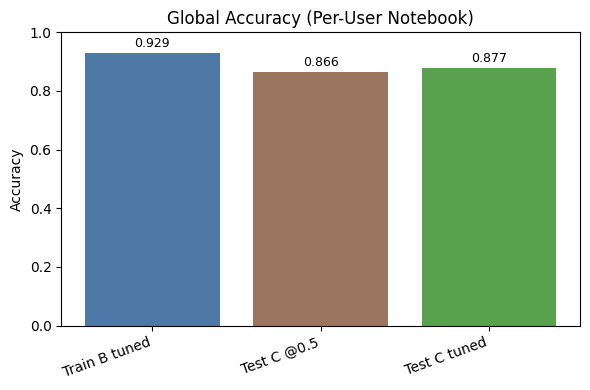

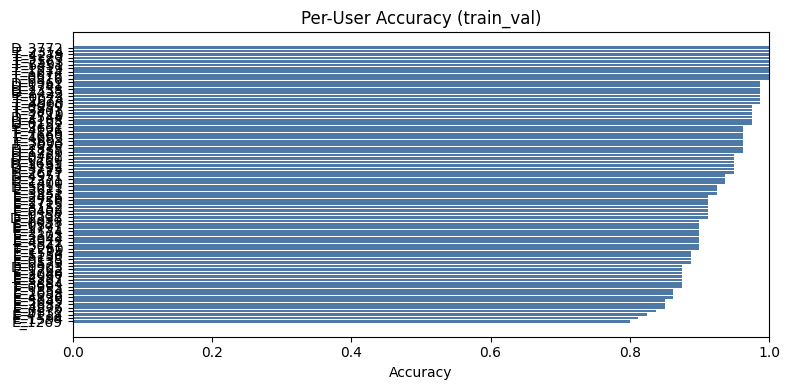

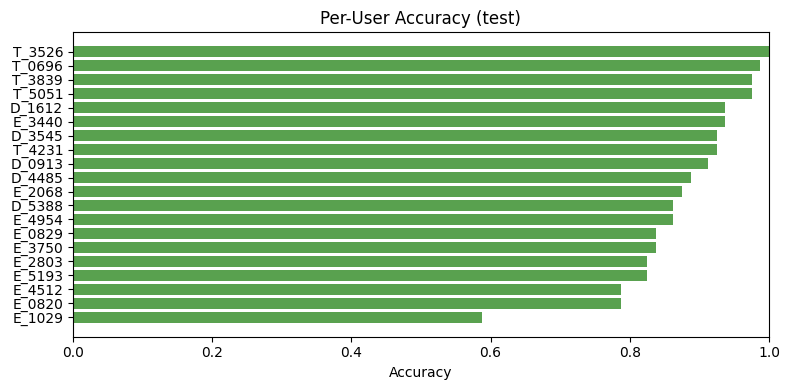

In [7]:
# Diagrams: global B/C accuracy and per-user accuracy
mB = results['metrics_train_val_tuned_threshold']; mC = results['metrics_test_tuned_threshold']; mC05 = results['metrics_test_default_threshold_0_5']
fig, ax = plt.subplots(figsize=(6,4))
labels = ['Train B tuned', 'Test C @0.5', 'Test C tuned']
vals = [mB['accuracy'], mC05['accuracy'], mC['accuracy']]
ax.bar(labels, vals, color=['#4e79a7','#9c755f','#59a14f'])
ax.set_ylim(0,1); ax.set_ylabel('Accuracy'); ax.set_title('Global Accuracy (Per-User Notebook)')
for i,v in enumerate(vals): ax.text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

for split_name, color in [('train_val', '#4e79a7'), ('test', '#59a14f')]:
    g = per_user_df[per_user_df['split']==split_name].sort_values('accuracy')
    if g.empty: continue
    fig, ax = plt.subplots(figsize=(8,4))
    ax.barh(g['speaker_id'], g['accuracy'], color=color)
    ax.set_xlim(0,1); ax.set_xlabel('Accuracy'); ax.set_title(f'Per-User Accuracy ({split_name})')
    plt.tight_layout(); plt.show()


,split,group,speaker_id,n_samples,n_bonafide,n_spoof,accuracy,auc,bonafide_recall,spoof_recall,fp_bonafide_as_spoof,fn_spoof_as_bonafide
7,test,test,E_1029,80,32,48,0.5875,0.660807,0.00000,0.979167,32,1
5,test,test,E_0820,80,32,48,0.7875,0.963542,1.00000,0.645833,0,17
12,test,test,E_4512,80,32,48,0.7875,0.893229,0.59375,0.916667,13,4
14,test,test,E_5193,80,32,48,0.8250,0.928385,0.84375,0.812500,5,9
9,test,test,E_2803,80,32,48,0.8250,0.931641,0.96875,0.729167,1,13
11,test,test,E_3750,80,32,48,0.8375,0.936849,0.84375,0.833333,5,8
6,test,test,E_0829,80,32,48,0.8375,0.973958,0.59375,1.000000,13,0
13,test,test,E_4954,80,32,48,0.8625,0.965495,0.81250,0.895833,6,5
4,test,test,D_5388,80,32,48,0.8625,0.977214,0.68750,0.979167,10,1
8,test,test,E_2068,80,32,48,0.8750,0.957682,0.96875,0.812500,1,9


Weakest test user: E_1029


,group,speaker_id,utt_id,label_str,label_id,system_id,split,prob_spoof,pred_label_id,pred_label_str
6960,test,E_1029,E_0000727639,bonafide,0,bonafide,test,0.996751,1,spoof
6961,test,E_1029,E_0001052866,bonafide,0,bonafide,test,0.986265,1,spoof
6962,test,E_1029,E_0001243342,bonafide,0,bonafide,test,0.710165,1,spoof
6963,test,E_1029,E_0001550547,bonafide,0,bonafide,test,0.976310,1,spoof
6964,test,E_1029,E_0001902789,bonafide,0,bonafide,test,0.969827,1,spoof


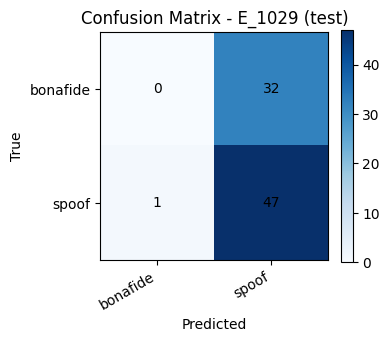

In [8]:
# Inspect weakest/strongest test users quickly
c_users = per_user_df[per_user_df['split']=='test'].sort_values('accuracy')
display(c_users)
if len(c_users):
    weak_spk = c_users.iloc[0]['speaker_id']
    g = pred_all[(pred_all['split']=='test') & (pred_all['speaker_id']==weak_spk)]
    print('Weakest test user:', weak_spk)
    display(g.head())
    cm = confusion_matrix(g['label_id'], g['pred_label_id']).tolist()
    plot_confmat(cm, f'Confusion Matrix - {weak_spk} (test)')
    plt.show()
